In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os
import glob
from PIL import Image
# фиксируем seed для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

/Users/grushinda/miniconda3/envs/nn_project/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/Users/grushinda/miniconda3/envs/nn_project/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Resuming download from 812646400 bytes (488846095 bytes left)...
Resuming download to /Users/grushinda/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/1.archive (812646400/1301492495) bytes left.


100%|██████████| 1.21G/1.21G [00:24<00:00, 19.6MB/s]

Extracting files...


Path to dataset files: /Users/grushinda/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1


In [2]:
possible_paths = [
    "/Users/grushinda/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1",
    #"/kaggle/input/gtzan-dataset-music-genre-classification",
    #"/root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1",
]

dataset_path = None
for path in possible_paths:
    if os.path.exists(path):
        dataset_path = path
        break

if dataset_path is None:
    print("Датасет не найден!")
    import sys
    sys.exit(1)

print(f"Датасет найден: {dataset_path}")

# определяем путь к данным
if os.path.exists(os.path.join(dataset_path, "Data")):
    data_path = os.path.join(dataset_path, "Data")
else:
    data_path = dataset_path

image_path = os.path.join(data_path, "images_original")
#csv_path = os.path.join(data_path, "features_30_sec.csv")

print(f"Изображения: {image_path} (существует: {os.path.exists(image_path)})")
#print(f"CSV: {csv_path} (существует: {os.path.exists(csv_path)})")

if not os.path.exists(image_path) : #or not os.path.exists(csv_path):
    print("Ошибка: данные не найдены!")
    import sys
    sys.exit(1)

Датасет найден: /Users/grushinda/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1
Изображения: /Users/grushinda/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data/images_original (существует: True)


In [3]:
image_data = []      # изображения
image_labels = []    # метки из изображений
csv_labels = []      # метки из CSV
valid_filenames = [] # имена файлов для проверки

# проходим по жанрам в папке
class_names = sorted([d for d in os.listdir(image_path) if os.path.isdir(os.path.join(image_path, d))])
print(f"Найдены жанры: {class_names}")

Найдены жанры: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [4]:
# Проходим по каждой папке ...
for class_idx, class_name in enumerate(class_names):
    # путь к кккаждой папке ...
    class_dir = os.path.join(image_path, class_name)
    # print(class_dir)
    # путьь к каждому файлу в папке class_dir
    image_files = sorted(glob.glob(os.path.join(class_dir, "*.png")))
    #print(image_files)
    # в цикле по каждому файлу 
    for img_path in image_files:
        # обрезаем расширение 
        img_name = os.path.basename(img_path).replace('.png', '')

        # Заггружаем изображения ...
        img = Image.open(img_path).convert('RGB')
        image_data.append(img)
        image_labels.append(class_idx)
        valid_filenames.append(img_name)
print(f"Загруженно: {len(image_data)} изображений")        

Загруженно: 999 изображений


In [5]:

print(class_names)

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


Визуализация изображений


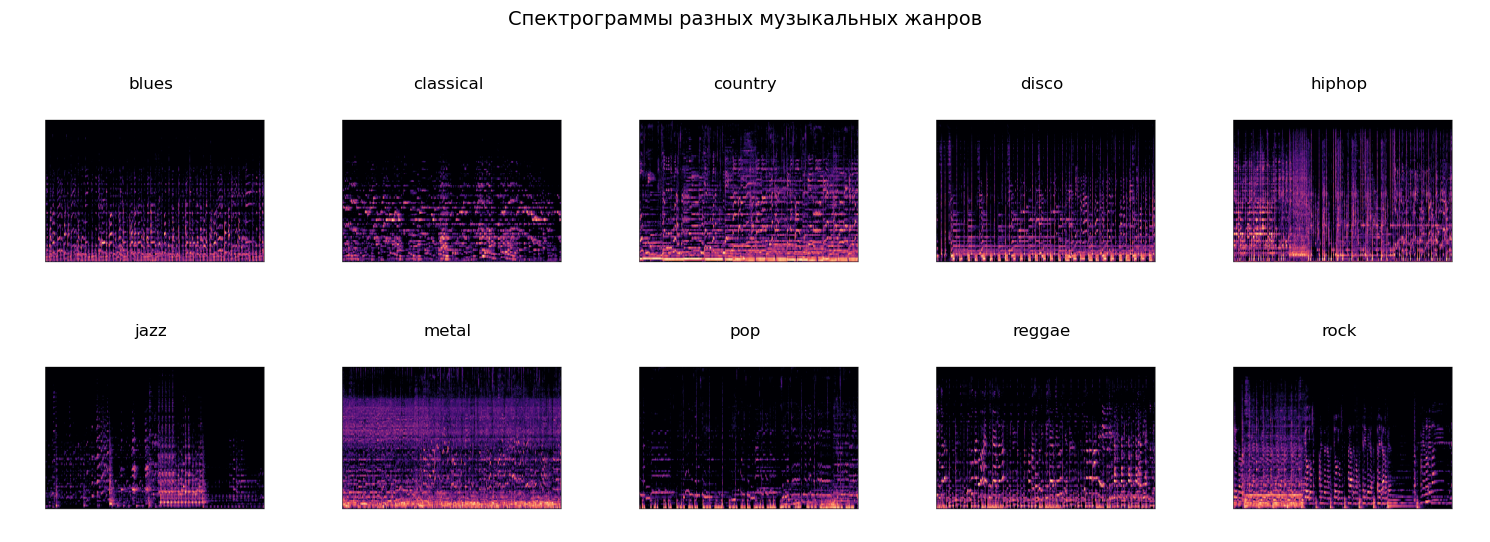

In [6]:
# для каждого жанра выбираем первый попавшийся файл
sample_images = []
for class_name in class_names:
    class_dir = os.path.join(image_path, class_name)
    # берём первый файл .png
    files = sorted([f for f in os.listdir(class_dir) if f.endswith('.png')])
    if files:
        img_path = os.path.join(class_dir, files[0])
        img = Image.open(img_path)
        sample_images.append((img, class_name))

# создаём сетку 2x5 (10 жанров)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for idx, (img, genre) in enumerate(sample_images):
    row, col = idx // 5, idx % 5
    axes[row, col].imshow(img, cmap='viridis')
    axes[row, col].set_title(genre, fontsize=12)
    axes[row, col].axis('off')

plt.suptitle('Спектрограммы разных музыкальных жанров', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Создание тензоров

In [7]:
# трансформации для изображений
# С помощью конвеера выполняем преобразования под требования вх/ данных pytorch
image_transform = transforms.Compose([
    transforms.Resize((64, 64)), # все изображения сжимаем до 64x64 пикселей (размер в батче должен быть одинаковый)
    transforms.ToTensor(), # преобразукм в тензор + стандартизация (делим на 255 получим диапазон (0 , 1)
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # нормализация сдвиггаем диапазон на (-1,1) out = (in - mean) / std
])

# преобразуем изображения в тензоры
X_images = torch.stack([image_transform(img) for img in image_data]) # объединяем в один батч 
y_images = torch.tensor(image_labels) # 
print(f"  Изображения: {X_images.shape}")

  Изображения: torch.Size([999, 3, 64, 64])


# 3. Разделение данных

In [8]:
# делим индексы (а не данные) на три блока
def split_data(n_samples,        # общий объем = 999
               train_ratio=0.7,  # - обучение 70%
               val_ratio=0.15,   # - валидация обучения 15%
               test_ratio=0.15): # - тестовая выборка  15%
    
    indices = np.random.permutation(n_samples) # перемешиваем индексы 
    train_end = int(train_ratio * n_samples)   # получаем кол-во 
    val_end = train_end + int(val_ratio * n_samples) # получаем кол-во 
    
    return indices[:train_end], indices[train_end:val_end], indices[val_end:] 

n_samples = len(X_images) # = 999

train_idx, val_idx, test_idx = split_data(n_samples)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Train: 699, Val: 149, Test: 151


In [9]:
def show_tensor_image(tensor):

    img = tensor[1].clone().detach()
    img = img * 0.5 + 0.5 #Возвращаем данные до нормализации
    img = img.permute(1, 2, 0) # Меняем порядок осей: из (C, H, W) в (H, W, C)

    plt.imshow(img.numpy())
    plt.axis("off")  # Прячем оси с координатами пикселей
    plt.show()

In [10]:
# создаём датасеты для изображений
train_images = TensorDataset(X_images[train_idx], y_images[train_idx])
val_images = TensorDataset(X_images[val_idx], y_images[val_idx])
test_images = TensorDataset(X_images[test_idx], y_images[test_idx])

In [11]:
#show_tensor_image(X_images)

In [12]:
# DataLoader
batch_size = 64
train_loader_images = DataLoader(train_images, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_images = DataLoader(val_images, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader_images = DataLoader(test_images, batch_size=batch_size, shuffle=False, num_workers=2)
print(f"Image loaders: Train={len(train_loader_images)}, Val={len(val_loader_images)}, Test={len(test_loader_images)}")

Image loaders: Train=11, Val=3, Test=3


# 4. Архитектуры моделей

In [13]:
class CNNImages(nn.Module):
    def __init__(self, input_size=64*64*3, hidden_sizes=[512, 256], num_classes=10, dropout_rate=0.3):
        super(CNNImages, self).__init__()

        # делаем свертку 
        self.features = nn.Sequential(
            # первый слой 3 - канала (RGB) 32 фильтра 
            # Количество фильтров в слое = 32 каждый размером =  kernel_size*kernel_size * 3 входные канала  (RGB)
            # на выходе 32 канала = кол-во фильтров на входе 

            
            # свертка kernel_size - 3х3/ padding - доп 0 вокруг изображения для возможности сдвинуть сканирующее окно
            # эталонно padding = (kernel_size  - 1) /  2
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),  
            # активация                                             
            nn.ReLU(),
            # уменьшаем размерность в 2. kernel_size - сканир окно 2х2 / stride - шаг окна                                   
            nn.MaxPool2d(kernel_size=2, stride=2),       

            # второй слой 32 - канала и 64 фильтра 
            # Количество фильтров в слое = 64 каждый размером = kernel_size*kernel_size * 32 входные канала  
            # на выходе 64 канала = кол-во фильтров на входе                
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),


            # третий слой 64 - канала и 128 фильтра 
            # Количество фильтров в слое = 128 каждый размером = kernel_size*kernel_size * 64 входные канала  
            # на выходе 64 канала = кол-во фильтров на входе   
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        
        # На выходе сверки получаем
        # Полносвязный слой 
        # Кол-во каналов = 128 (выход последнего слоя)
        # после 3-х MaxPool2d картинка уменьшилась до 8*8 64/2 = 32 / 2 = 16 / 2 = 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # 128 - кол-во каналов
            #8*8 - размер картинки в пикселях 
            # 256-  нейроны в скрытом слое 
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, 10) # на выходе 10 парметров - 10 жанров музыки
        )

        #Итого преобразовагия 
        #3 (Цвет) -> 32 (Линии) -> 64 (Узоры) -> 128 (Части объектов) -> Выпрямление в вектор


    def forward(self, x):
        return self.classifier(self.features(x))

In [14]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNImages().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=0.001)

epochs = 50

print(device)
print(model)
print(criterion)
print(optimizer)


cpu
CNNImages(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
CrossEntropyLoss()
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fu

In [ ]:

for epoch in range(epochs):
    # --- Фаза обучения ---
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    # идем циклом по картинкам для обучения 
    for images, labels in train_loader_images:
        # переносим данные на устройсво (которе выбрали выше что смогли скорее)
        images, labels = images.to(device), labels.to(device)

        #обнуляем градиенты 
        optimizer.zero_grad()

        # проходим прямой проход 
        outputs = model(images)
        # Считаем потери criterion - функция потерь
        loss = criterion(outputs, labels) 
        # проходим обратный проход 
        loss.backward()

        # обновляем веса в моделе
        optimizer.step()

        # расчет ошибки
        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        #сравниванем предсказание с эталоном - (labels)
        correct_train += predicted.eq(labels).sum().item()

    # считаем общую статистику
    epoch_train_loss = train_loss / total_train
    epoch_train_acc = 100.0 * correct_train / total_train

    # --- валидация  ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # отключаем градиент - ибо валидация
    with torch.no_grad():
        for images, labels in val_loader_images:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()
            
    epoch_test_loss = val_loss / total_val
    epoch_test_acc = 100.0 * correct_val / total_val
    
    # 
    if (epoch + 1) == 1 or (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
        print(f"Эпоха [{epoch+1}/{epochs}]")
        print(f"  Обучение -> Потери: {epoch_train_loss:.4f} | Точность: {epoch_train_acc:.2f}%")
        print(f"  Валидация -> Потери: {epoch_test_loss:.4f} | Точность: {epoch_test_acc:.2f}%")
        print("-" * 50)

Эпоха [1/50]
  Обучение -> Потери: 2.3164 | Точность: 10.44%
  Валидация -> Потери: 2.3081 | Точность: 3.36%
--------------------------------------------------
Эпоха [5/50]
  Обучение -> Потери: 1.9124 | Точность: 28.76%
  Валидация -> Потери: 1.8638 | Точность: 35.57%
--------------------------------------------------
Эпоха [10/50]
  Обучение -> Потери: 1.5955 | Точность: 45.78%
  Валидация -> Потери: 1.7221 | Точность: 41.61%
--------------------------------------------------
Эпоха [15/50]
  Обучение -> Потери: 1.4675 | Точность: 48.07%
  Валидация -> Потери: 1.8217 | Точность: 41.61%
--------------------------------------------------
Эпоха [20/50]
  Обучение -> Потери: 1.1944 | Точность: 58.80%
  Валидация -> Потери: 1.5841 | Точность: 47.65%
--------------------------------------------------
Эпоха [25/50]
  Обучение -> Потери: 0.9894 | Точность: 64.52%
  Валидация -> Потери: 1.6136 | Точность: 52.35%
--------------------------------------------------
Эпоха [30/50]
  Обучение -> Пот

In [16]:
model.eval()
test_loss = 0.0
correct_test = 0
total_test = 0
    
with torch.no_grad():
    for images, labels in test_loader_images:
        images, labels = images.to(device), labels.to(device)
            
        outputs = model(images)
        loss = criterion(outputs, labels)
            
        test_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_test += labels.size(0)
        correct_test += predicted.eq(labels).sum().item()
            
total_test_loss = test_loss / total_test
total_test_acc = 100.0 * correct_test / total_test
    
print(f"  Тест     -> Потери: {total_test_loss:.4f} | Точность: {total_test_acc:.2f}%")
print("-" * 50)

  Тест     -> Потери: 1.9035 | Точность: 56.29%
--------------------------------------------------
